### **Шаг 1. Загрузка данных**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

## **Шаг 2. Первичный анализ (EDA — базовый)**

In [4]:
df.head(3)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.tail(3)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

## **Шаг 3. Чистим НЕнужные колонки**

In [9]:
df = df.drop('Transaction ID', axis=1)

In [10]:
df = df.drop('Customer ID', axis=1)

In [11]:
df.head(3)

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2023-11-24,Male,34,Beauty,3,50,150
1,2023-02-27,Female,26,Clothing,2,500,1000
2,2023-01-13,Male,50,Electronics,1,30,30


In [12]:
df = df.drop('Date', axis=1)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Gender            1000 non-null   object
 1   Age               1000 non-null   int64 
 2   Product Category  1000 non-null   object
 3   Quantity          1000 non-null   int64 
 4   Price per Unit    1000 non-null   int64 
 5   Total Amount      1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


## **Шаг 4 Работа с пропусками в данных**

In [14]:
df['Gender'].value_counts(dropna=False)

Gender
Female    510
Male      490
Name: count, dtype: int64

In [15]:
df['Product Category'].value_counts(dropna=False)

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [16]:
df['Gender'].fillna('Неизвестный Гендер', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_10368\2202917155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna('Неизвестный Гендер', inplace=True)


In [17]:
df['Product Category'].fillna('Неизвестный Продукт', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_10368\2654746432.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product Category'].fillna('Неизвестный Продукт', inplace=True)


In [18]:
df.isnull().sum()

Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## **Шаг 5 Разведочный анализ данных - EDA**

In [19]:
df

,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,Male,34,Beauty,3,50,150
1,Female,26,Clothing,2,500,1000
2,Male,50,Electronics,1,30,30
3,Male,37,Clothing,1,500,500
4,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...
995,Male,62,Clothing,1,50,50
996,Male,52,Beauty,3,30,90
997,Female,23,Beauty,4,25,100
998,Female,36,Electronics,3,50,150


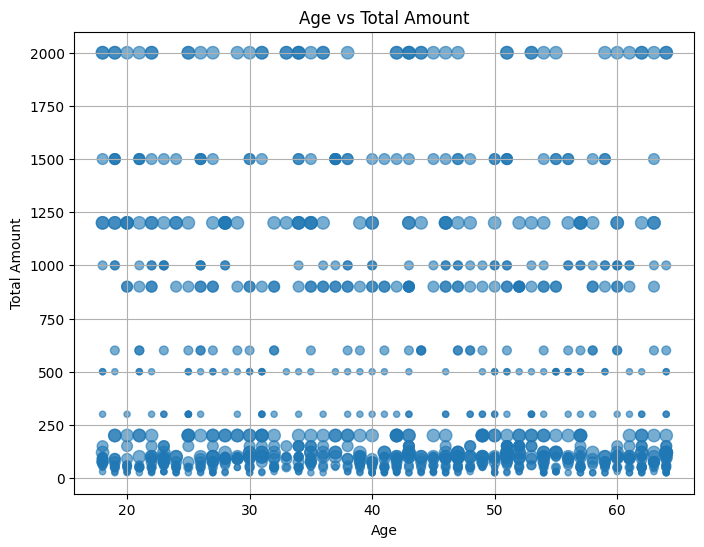

In [127]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Age'],
    df['Total Amount'],
    s=df['Quantity'] * 20,
    alpha=0.6
)

plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.grid(True)
plt.show()

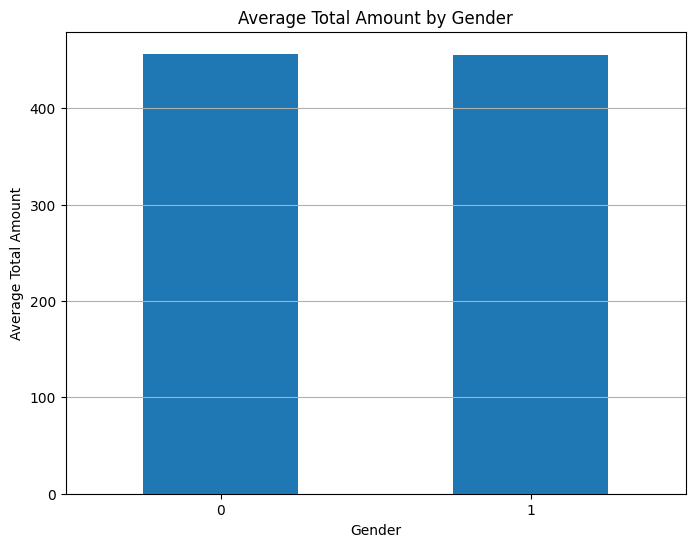

In [128]:
gender_avg = df.groupby('Gender')['Total Amount'].mean()

gender_avg.plot(kind='bar', figsize=(8, 6))
plt.title("Average Total Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Total Amount")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


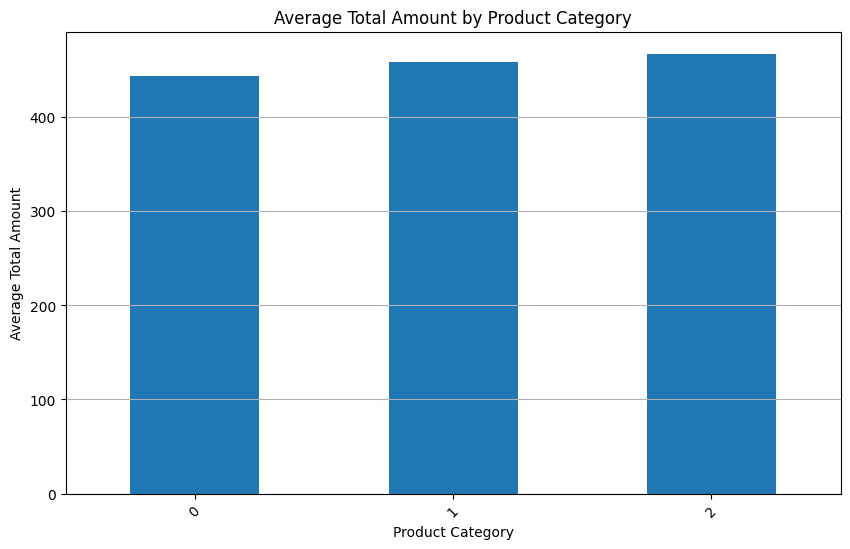

In [129]:
category_avg = df.groupby('Product Category')['Total Amount'].mean()

category_avg.plot(kind='bar', figsize=(10, 6))
plt.title("Average Total Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Total Amount")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

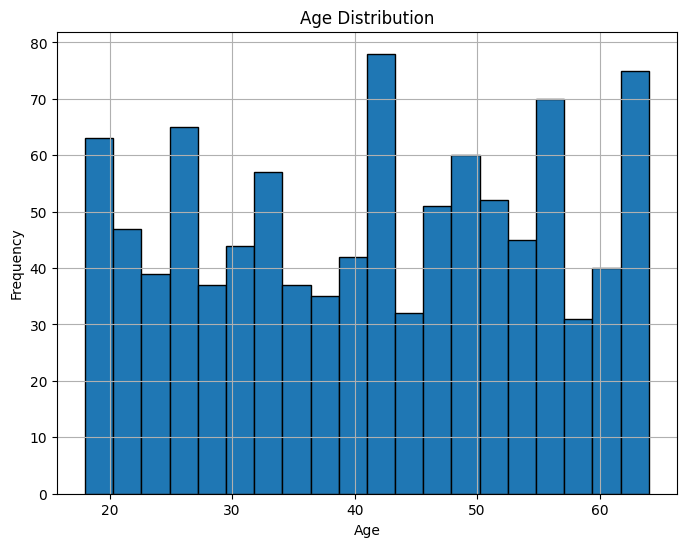

In [130]:
plt.figure(figsize=(8, 6))

plt.hist(df['Age'], bins=20, edgecolor='black')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

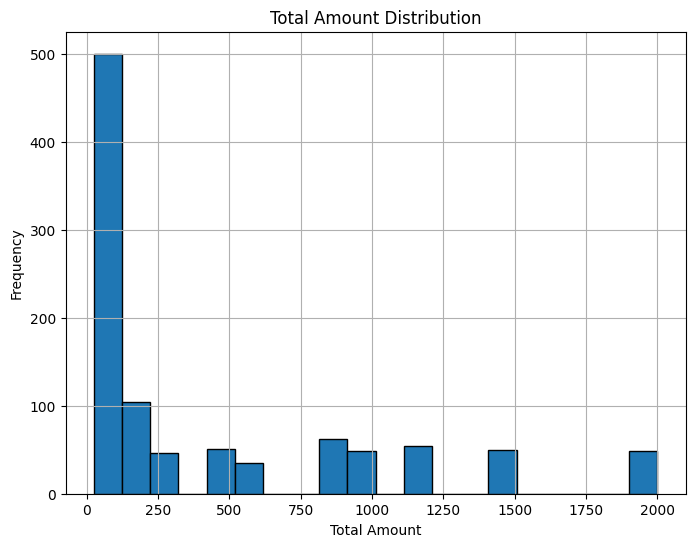

In [131]:
plt.figure(figsize=(8, 6))

plt.hist(df['Total Amount'], bins=20, edgecolor='black')

plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## **Шаг 6 Кодирование данных (Label or OneHot Encoding)**

In [20]:
#df = pd.get_dummies(df, drop_first=True)

In [21]:
df['Gender'].value_counts(dropna=False).index

Index(['Female', 'Male'], dtype='object', name='Gender')

In [22]:
df['Gender'].replace(['Female', 'Male'], [0 ,1], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_10368\3892309217.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(['Female', 'Male'], [0 ,1], inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_10368\3892309217.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].

In [23]:
df['Gender'].value_counts()

Gender
0    510
1    490
Name: count, dtype: int64

In [24]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [25]:
df['Product Category'].value_counts().index

Index(['Clothing', 'Electronics', 'Beauty'], dtype='object', name='Product Category')

In [26]:
df['Product Category'].replace(['Clothing', 'Electronics', 'Beauty'], [0, 1, 2], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_10368\53501670.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product Category'].replace(['Clothing', 'Electronics', 'Beauty'], [0, 1, 2], inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_10368\53501670.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcast

In [27]:
df['Product Category'].value_counts()

Product Category
0    351
1    342
2    307
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Gender            1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Product Category  1000 non-null   int64
 3   Quantity          1000 non-null   int64
 4   Price per Unit    1000 non-null   int64
 5   Total Amount      1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


## **7. Корреляционный анализ**

In [29]:
df.corr()

,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
Gender,1.000000,0.002621,-0.035662,-0.028023,-0.000961,-0.001001
Age,0.002621,1.000000,-0.045932,-0.023737,-0.038423,-0.060568
Product Category,-0.035662,-0.045932,1.000000,-0.013504,0.021133,0.017644
Quantity,-0.028023,-0.023737,-0.013504,1.000000,0.017501,0.373707
Price per Unit,-0.000961,-0.038423,0.021133,0.017501,1.000000,0.851925
Total Amount,-0.001001,-0.060568,0.017644,0.373707,0.851925,1.000000


## **8. Моделирование**

### **1. Создание переменных X и Y [Выбор элементов (признаков) входных данных]**

In [30]:
df.head()

,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,34,2,3,50,150
1,0,26,0,2,500,1000
2,1,50,1,1,30,30
3,1,37,0,1,500,500
4,1,30,2,2,50,100


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Gender            1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Product Category  1000 non-null   int64
 3   Quantity          1000 non-null   int64
 4   Price per Unit    1000 non-null   int64
 5   Total Amount      1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


In [32]:
df.columns

Index(['Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit',
       'Total Amount'],
      dtype='object')

In [33]:
X = df[['Gender', 'Age', 'Product Category', 'Quantity']]
Y = df['Price per Unit']

In [34]:
X.shape, Y.shape

((1000, 4), (1000,))

### **2. Разделение набора данных на Train и Test**

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X.values, Y.values, test_size=0.10, random_state=10)

In [37]:
X_train

array([[ 0, 45,  0,  1],
       [ 1, 29,  0,  4],
       [ 0, 26,  1,  3],
       ...,
       [ 1, 52,  2,  3],
       [ 0, 28,  0,  3],
       [ 0, 19,  1,  2]], shape=(900, 4))

In [38]:
X.shape, X_train.shape, Y_train.shape, X_test.shape, Y_test.shape,

((1000, 4), (900, 4), (900,), (100, 4), (100,))


### **3. Обучение модели**

In [39]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train, Y_train)
LR.score(X_test, Y_test)

-0.007866854960582703

#### **4. Тестирование модели**

In [40]:
LR_pred = LR.predict(X_test)
LR_pred

array([169.4557677 , 172.13598463, 180.38635093, 181.81177982,
       187.96425216, 181.25683795, 168.73223518, 186.45237898,
       188.51069847, 191.2484282 , 185.07132229, 189.71192145,
       169.72229561, 186.17246057, 194.62754407, 166.81142742,
       179.00529423, 169.72899086, 192.02552578, 174.73775302,
       177.54423861, 180.75296353, 176.27425977, 173.65455305,
       172.52878119, 186.72560214, 179.93329405, 190.30249006,
       187.64021145, 169.44907245, 165.87218453, 181.67426809,
       198.1603097 , 178.95447669, 173.90983789, 175.33501688,
       185.02050474, 193.75705705, 174.15842748, 163.48312909,
       194.48333709, 171.71855449, 184.79809913, 180.53055791,
       186.42774541, 179.80702539, 184.40530256, 181.9983088 ,
       177.83540008, 175.44634464, 179.42272438, 176.49666538,
       166.71803798, 179.19182321, 185.11364428, 181.87204013,
       186.72560214, 169.77980841, 179.53380223, 181.94749125,
       166.12077412, 168.71429686, 173.7053706 , 178.03

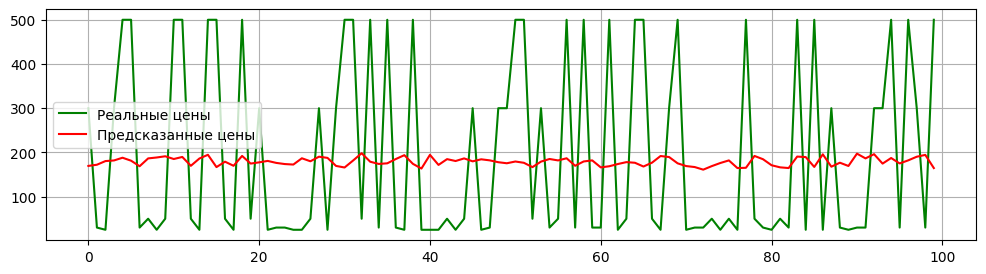

In [41]:
plt.figure(figsize=(12, 3))
plt.plot(Y_test[:200], color='g', label='Реальные цены')
plt.plot(LR_pred[:200], color='r', label='Предсказанные цены')
plt.grid()
plt.legend()
plt.show()

### **Моя практика на LR**

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
LR = LinearRegression()
LR.fit(X_train, Y_train)
LR.score(X_test, Y_test)

-0.007866854960582703

In [44]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train, Y_train)
LR.score(X_test, Y_test)
My_pred = LR.predict(X_test)
My_pred

array([169.4557677 , 172.13598463, 180.38635093, 181.81177982,
       187.96425216, 181.25683795, 168.73223518, 186.45237898,
       188.51069847, 191.2484282 , 185.07132229, 189.71192145,
       169.72229561, 186.17246057, 194.62754407, 166.81142742,
       179.00529423, 169.72899086, 192.02552578, 174.73775302,
       177.54423861, 180.75296353, 176.27425977, 173.65455305,
       172.52878119, 186.72560214, 179.93329405, 190.30249006,
       187.64021145, 169.44907245, 165.87218453, 181.67426809,
       198.1603097 , 178.95447669, 173.90983789, 175.33501688,
       185.02050474, 193.75705705, 174.15842748, 163.48312909,
       194.48333709, 171.71855449, 184.79809913, 180.53055791,
       186.42774541, 179.80702539, 184.40530256, 181.9983088 ,
       177.83540008, 175.44634464, 179.42272438, 176.49666538,
       166.71803798, 179.19182321, 185.11364428, 181.87204013,
       186.72560214, 169.77980841, 179.53380223, 181.94749125,
       166.12077412, 168.71429686, 173.7053706 , 178.03

In [46]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(Y_test, My)*100

307.2946200006913

### Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
LR = LinearRegression()
LR.fit(X_train, Y_train)
LR_pred = LR.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, LR_pred)

187.61000915565464

In [52]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, LR_pred)

41714.28630157138

In [53]:
from sklearn.metrics import r2_score
r2_score(Y_test, LR_pred)

-0.007866854960582703

In [54]:
from sklearn.linear_model import Ridge

In [55]:
RD = Ridge()
RD.fit(X_train, Y_train)
RD_pred = RD.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, RD_pred)

187.61027065875425

In [57]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, RD_pred)

41714.21393373756

In [58]:
from sklearn.metrics import r2_score
r2_score(Y_test, RD_pred)

-0.007865106467499494

In [59]:
from sklearn.linear_model import Lasso

In [60]:
LS = Lasso()
LS.fit(X_train, Y_train)
LS_pred = LS.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, LS_pred)

187.662312878019

In [62]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, LS_pred)

41701.78134711745

In [63]:
from sklearn.metrics import r2_score
r2_score(Y_test, LS_pred)

-0.007564720362718713

###  Decision Tree Regressor

In [64]:
from sklearn.tree import DecisionTreeRegressor

In [65]:
DTR = DecisionTreeRegressor()
DTR.fit(X_train, Y_train)
DTR_pred = DTR.predict(X_test)

In [66]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, DTR_pred)

221.425

In [67]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, DTR_pred)

83089.39583333333

In [68]:
from sklearn.metrics import r2_score
r2_score(Y_test, DTR_pred)

-1.0075387950713184

### Random Forest Regressor

In [69]:
from sklearn.ensemble import RandomForestRegressor

In [70]:
RFR = RandomForestRegressor()
RFR.fit(X_train, Y_train)
RFR_pred = RFR.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, RFR_pred)

206.12540575396827

In [72]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, RFR_pred)

57858.476860661016

In [73]:
from sklearn.metrics import r2_score
r2_score(Y_test, RFR_pred)

-0.3979297328686979

### Gradient Boosting Regressor

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

In [75]:
GBR = GradientBoostingRegressor()
GBR.fit(X_train, Y_train)
GBR_pred = GBR.predict(X_test)

In [76]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, GBR_pred)

193.51827186573328

In [77]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, GBR_pred)

46145.30162880889

In [78]:
from sklearn.metrics import r2_score
r2_score(Y_test, GBR_pred)

-0.11492546432666884

###  Ada Boost Regressor

In [79]:
from sklearn.ensemble import AdaBoostRegressor

In [80]:
ABR = AdaBoostRegressor()
ABR.fit(X_train, Y_train)
ABR_pred = ABR.predict(X_test)

In [81]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, ABR_pred)

195.3268047290734

In [82]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, ABR_pred)

42543.49543658728

In [83]:
from sklearn.metrics import r2_score
r2_score(Y_test, ABR_pred)

-0.027901535572667946

In [84]:
from sklearn.svm import SVR

In [85]:
GBR = GradientBoostingRegressor()
GBR.fit(X_train, Y_train)
GBR_pred = GBR.predict(X_test)

In [86]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, GBR_pred)

193.51827186573328

In [87]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, GBR_pred)

46145.30162880889

In [88]:
from sklearn.metrics import r2_score
r2_score(Y_test, GBR_pred)

-0.11492546432666884

### KNeighbors Regressor

In [89]:
from sklearn.neighbors import KNeighborsRegressor

In [90]:
KNNR = KNeighborsRegressor()
KNNR.fit(X_train, Y_train)
KNNR_pred = KNNR.predict(X_test)

In [91]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, KNNR_pred)

200.2

In [92]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, KNNR_pred)

52763.02

In [93]:
from sklearn.metrics import r2_score
r2_score(Y_test, KNNR_pred)

-0.2748174244471995

### XGB Regressor

In [94]:
from xgboost import XGBRegressor

In [95]:
XGBR = XGBRegressor()
XGBR.fit(X_train, Y_train)
XGBR_pred = XGBR.predict(X_test)

In [96]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, XGBR_pred)

212.7866973876953

In [97]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, XGBR_pred)

68984.0078125

In [98]:
from sklearn.metrics import r2_score
r2_score(Y_test, XGBR_pred)

-0.6667360067367554

### LGBM Regressor

In [99]:
from lightgbm import LGBMRegressor

In [100]:
LGBMR = LGBMRegressor()
LGBMR.fit(X_train, Y_train)
LGBMR_pred = XGBR.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 900, number of used features: 4
[LightGBM] [Info] Start training from score 178.516667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [101]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, LGBMR_pred)

212.7866973876953

In [102]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, LGBMR_pred)

68984.0078125

In [103]:
from sklearn.metrics import r2_score
r2_score(Y_test, LGBMR_pred)

-0.6667360067367554

### Cat Boost Regressor

In [104]:
from catboost import CatBoostRegressor

In [105]:
CBR = CatBoostRegressor()
CBR.fit(X_train, Y_train)
CBR_pred = XGBR.predict(X_test)

Learning rate set to 0.040267
0:	learn: 187.8631803	total: 204ms	remaining: 3m 23s
1:	learn: 187.6093807	total: 205ms	remaining: 1m 42s
2:	learn: 187.5881012	total: 206ms	remaining: 1m 8s
3:	learn: 187.3065556	total: 207ms	remaining: 51.5s
4:	learn: 187.1899661	total: 208ms	remaining: 41.3s
5:	learn: 187.1366851	total: 208ms	remaining: 34.5s
6:	learn: 186.9431290	total: 210ms	remaining: 29.7s
7:	learn: 186.6995906	total: 211ms	remaining: 26.1s
8:	learn: 186.5950272	total: 212ms	remaining: 23.3s
9:	learn: 186.3974390	total: 213ms	remaining: 21.1s
10:	learn: 186.2019176	total: 215ms	remaining: 19.3s
11:	learn: 185.9948520	total: 216ms	remaining: 17.8s
12:	learn: 185.7183024	total: 217ms	remaining: 16.5s
13:	learn: 185.5134006	total: 219ms	remaining: 15.4s
14:	learn: 185.4471696	total: 220ms	remaining: 14.4s
15:	learn: 185.2659805	total: 221ms	remaining: 13.6s
16:	learn: 185.2187121	total: 222ms	remaining: 12.8s
17:	learn: 185.0046931	total: 223ms	remaining: 12.2s
18:	learn: 184.9023179	t

In [106]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, CBR_pred)

212.7866973876953

In [107]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test, CBR_pred)

68984.0078125

In [108]:
from sklearn.metrics import r2_score
r2_score(Y_test, CBR_pred)

-0.6667360067367554

### Универсальная метрика задачи регресии

In [109]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

def all_reg_metrics(model, model_name, X_test, Y_test):
    y_pred = model.predict(X_test)

    R2 = round(r2_score(Y_test, y_pred), 4)
    MAPE = round(mean_absolute_percentage_error(Y_test, y_pred)*100, 2)
    MAE = round(mean_absolute_error(Y_test, y_pred), 1)
    MSE = round(mean_squared_error(Y_test, y_pred), 1)
    RMSE = round(mean_squared_error(Y_test, y_pred), 1)
    print(model_name + ':')
    print(f'r2_score: {R2}, MAPE: {MAPE}, MAE: {MAE}, MSE: {MSE}, RMSE: {RMSE}')
    print(' ')

In [110]:
# 1. Linear Regression
all_reg_metrics(LR, 'LR', X_test, Y_test)

# 5. Decision Tree Regressor
all_reg_metrics(DTR, 'DTR', X_test, Y_test)

# 6. Random Forest Regressor
all_reg_metrics(RFR, 'RFR', X_test, Y_test)

# 8. K-Neighbors Regressor
all_reg_metrics(KNNR, 'KNNR', X_test, Y_test)

# 9. XGBoost Regressor
all_reg_metrics(XGBR, 'XGBR', X_test, Y_test)

# 10. Gradient Boosting Regressor
all_reg_metrics(GBR, 'GBR', X_test, Y_test)

# 11. AdaBoost Regressor
all_reg_metrics(ABR, 'ABR', X_test, Y_test)

# 12. CatBoost Regressor (агар истифода баред)
all_reg_metrics(CBR, 'CBR', X_test, Y_test)

# 13. LightGBM Regressor (агар истифода баред)
all_reg_metrics(LGBMR, 'LGBMR', X_test, Y_test)

LR:
r2_score: -0.0079, MAPE: 307.29, MAE: 187.6, MSE: 41714.3, RMSE: 41714.3
 
DTR:
r2_score: -1.0075, MAPE: 420.33, MAE: 221.4, MSE: 83089.4, RMSE: 83089.4
 
RFR:
r2_score: -0.3979, MAPE: 385.03, MAE: 206.1, MSE: 57858.5, RMSE: 57858.5
 
KNNR:
r2_score: -0.2748, MAPE: 352.23, MAE: 200.2, MSE: 52763.0, RMSE: 52763.0
 
XGBR:
r2_score: -0.6667, MAPE: 396.43, MAE: 212.8, MSE: 68984.0, RMSE: 68984.0
 
GBR:
r2_score: -0.1149, MAPE: 335.25, MAE: 193.5, MSE: 46145.3, RMSE: 46145.3
 
ABR:
r2_score: -0.0279, MAPE: 367.41, MAE: 195.3, MSE: 42543.5, RMSE: 42543.5
 
CBR:
r2_score: -0.3318, MAPE: 383.3, MAE: 205.0, MSE: 55123.1, RMSE: 55123.1
 
LGBMR:
r2_score: -0.1785, MAPE: 356.66, MAE: 197.0, MSE: 48776.2, RMSE: 48776.2
 


c:\Users\User\Desktop\Coding_in_Python\Python_inst\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Поиск наилучших гиперпараметров модели МО

In [111]:
CBR_model = CatBoostRegressor()

In [112]:
from sklearn.model_selection import GridSearchCV

In [113]:
CBR_param_grid = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

In [114]:
grid_search = GridSearchCV( estimator=CBR_model,
                           param_grid=CBR_param_grid,
                           cv=5,
                           scoring= 'r2',
                           n_jobs=-1)

In [115]:
grid_search.fit(X_train, Y_train)

0:	learn: 187.9163814	total: 1.44ms	remaining: 143ms
1:	learn: 187.8896632	total: 2.55ms	remaining: 125ms
2:	learn: 187.8710927	total: 3.47ms	remaining: 112ms
3:	learn: 187.8591935	total: 4.28ms	remaining: 103ms
4:	learn: 187.8505894	total: 4.96ms	remaining: 94.3ms
5:	learn: 187.8272704	total: 5.84ms	remaining: 91.5ms
6:	learn: 187.8080458	total: 6.67ms	remaining: 88.6ms
7:	learn: 187.7913347	total: 7.47ms	remaining: 85.9ms
8:	learn: 187.7741881	total: 8.64ms	remaining: 87.4ms
9:	learn: 187.7503762	total: 9.84ms	remaining: 88.5ms
10:	learn: 187.7319963	total: 10.6ms	remaining: 85.8ms
11:	learn: 187.7309668	total: 11.1ms	remaining: 81.3ms
12:	learn: 187.7058334	total: 11.8ms	remaining: 78.6ms
13:	learn: 187.6786944	total: 12.5ms	remaining: 76.6ms
14:	learn: 187.6502850	total: 13.1ms	remaining: 74.4ms
15:	learn: 187.6306100	total: 13.8ms	remaining: 72.4ms
16:	learn: 187.6056388	total: 14.5ms	remaining: 70.6ms
17:	learn: 187.5802184	total: 15.1ms	remaining: 68.6ms
18:	learn: 187.5622510	t

,estimator,<catboost.cor...001F6A0D80EB0>
,param_grid,"{'depth': [4, 6, ...], 'iterations': [100, 200, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.05, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


### **Переобучения и недообучения модели МО - Overfitting and Underfitting**

In [116]:
DTR= DecisionTreeRegressor(max_depth=5, random_state=99)
DTR.fit(X_train, Y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,99
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [117]:
train_pred = DTR.predict(X_train)
test_pred = DTR.predict(X_test)

In [118]:
r2_score(Y_train, train_pred), r2_score(Y_test, test_pred)

(0.06525342777533794, -0.13169663448472924)

### K-блочная кросс-валидатсия

In [119]:
from sklearn.model_selection import KFold, cross_val_score

In [120]:
CBR = CatBoostRegressor(n_estimators=5)

In [121]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [122]:
scores = cross_val_score(CBR, X, Y, cv=kf, scoring='r2', n_jobs=-1)
scores

array([-0.04422977, -0.03121735,  0.00323416, -0.01181613, -0.05688733])

In [123]:
scores.mean()

np.float64(-0.028183283404673687)

In [124]:
print(f"R2 дар ҳар як блок: {scores}")
print(f"Миёнаи R2 (Mean R2): {scores.mean():.4f}")
print(f"Инҳирофи стандартӣ (Std Dev): {scores.std():.4f}")

R2 дар ҳар як блок: [-0.04422977 -0.03121735  0.00323416 -0.01181613 -0.05688733]
Миёнаи R2 (Mean R2): -0.0282
Инҳирофи стандартӣ (Std Dev): 0.0217


### Stratified K-Fold Cross-Validation

In [125]:
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

# 1. Тақсим кардани Y ба гурӯҳҳо (Стратификатсия барои регрессия)
# Мо Y-ро ба 5 гурӯҳ тақсим мекунем, то StratifiedKFold кор кунад
y_bins = np.digitize(Y, np.linspace(Y.min(), Y.max(), 5))

# 2. Танзими StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Рӯйхат барои нигоҳ доштани натиҷаҳо
scores = []

# 3. Раванди Кросс-валидатсия
# Мо аз рӯи y_bins тақсим мекунем, вале моделро бо Y-и аслӣ меомӯзонем
for train_index, test_index in skf.split(X, y_bins):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    Y_train_fold, Y_test_fold = Y.iloc[train_index], Y.iloc[test_index]
    
    # Сохтани модел
    model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=False)
    
    # Омӯзиш
    model.fit(X_train_fold, Y_train_fold)
    
    # Пешгӯӣ ва ҳисоби R2
    preds = model.predict(X_test_fold)
    score = r2_score(Y_test_fold, preds)
    scores.append(score)

# 4. Натиҷаҳои ниҳоӣ
print(f"R2 дар ҳар як блок: {scores}")
print(f"Миёнаи R2 (Stratified): {np.mean(scores):.4f}")

R2 дар ҳар як блок: [-0.2978131841336107, -0.4002919302691992, -0.27534089086748237, -0.3226135896714035, -0.1441967759760725]
Миёнаи R2 (Stratified): -0.2881


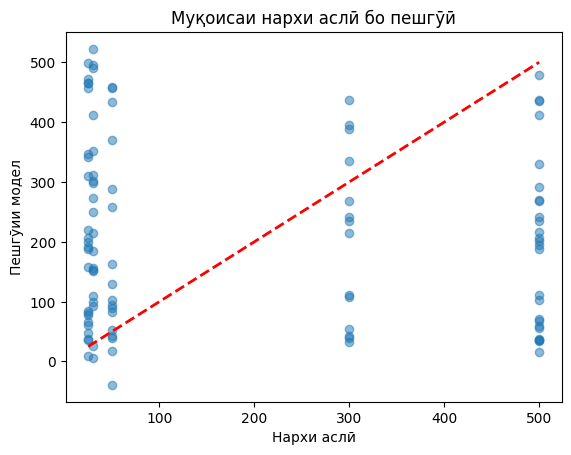

In [126]:
plt.scatter(Y_test, CBR_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Нархи аслӣ')
plt.ylabel('Пешгӯии модел')
plt.title('Муқоисаи нархи аслӣ бо пешгӯӣ')
plt.show()